<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/notebooks/10_multiagents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368

## Multiagents

Gustavo Freitas Alves

236249


---

Multi-agents with LangGraph. In total, I created 4 agents: the manager, the searcher, the answerer, and the summarizer. I am using gpt-4o-mini (gpt-5-nano) as the model.

I also built a chatbot using this multi-agent system with a Gradio interface.


---
## Imports

Dependências necessárias

In [ ]:
!pip -q install -U langchain langchain-community langchain-openai langgraph faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.2/467.2 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.6/207.6 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take

In [ ]:
import os
import re
from typing import TypedDict


import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
import gradio as gr
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import Image, display
from google.colab import files

# --- LangChain / LangGraph ---
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.tools import Tool
from langchain_openai import ChatOpenAI
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS as faiss
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

---
## Documentos

Para o caso dos documentos fiz o processamento em outro notebook (para deixar esse mais limpo e focado na parte do agente).

[Notebook processamento](https://colab.research.google.com/drive/1NktQsqtRTwsnH1MnhGsqSmniNaoZLTWc?authuser=2)

Utilizei segmentação por caracteres (infelizmente, por sentenças os chunks ficaram com uma qualidade ruim)

Obtendo os textos indexados

In [ ]:
%%time
uploaded = files.upload()

Saving index.faiss to index.faiss
Saving index.pkl to index.pkl
CPU times: user 11.3 s, sys: 18.9 s, total: 30.1 s
Wall time: 4min 37s


In [ ]:
!mkdir faiss_taxqa
!mv index.faiss index.pkl faiss_taxqa/

In [ ]:
%%capture
if 'model' not in globals() or 'index' not in globals():
  model = HuggingFaceEmbeddings(
        model_name = "neuralmind/bert-base-portuguese-cased",
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}
  )

  if not os.path.exists('faiss_taxqa'):
    raise('Import faiss files (.faiss and .pkl)')

  index = faiss.load_local("faiss_taxqa", model, allow_dangerous_deserialization=True)

---
## Agente

#### Definindo o modelo de LLM

**gpt-5-nano**

In [ ]:
# Insert here your key
KEY = ''
os.environ['OPENAI_API_KEY'] = KEY

In [ ]:
# modelo de LLM
llm = ChatOpenAI(
    model='gpt-5-nano',
    temperature=0
)

Breve checagem de funcionamento

In [ ]:
response = llm.invoke('Você pode pesquisar informação fora do seu conhecimento?')

In [ ]:
response.content

'Depende do ambiente em que você está usando eu.\n\n- Se a ferramenta de navegação/“navegar na web” estiver disponível e ligada, posso pesquisar na internet em tempo real, trazer informações atuais e citar fontes.\n- Se não houver navegador integrado, eu não consigo buscar na web; vou usar apenas o meu conhecimento já treinado (dados até o meu último treinamento) e posso ajudar a interpretar ou resumir o que já sei, ou você pode me fornecer fontes/links para eu analisar.\n\nSe quiser informações atuais, você pode me dizer o que procura ou me fornecer um link, e eu ajudo a resumir e comparar fontes. Quer que eu tente pesquisar algo específico?'

---

### Contrução do grafo

Representação simples do meu grafo dos multiagentes

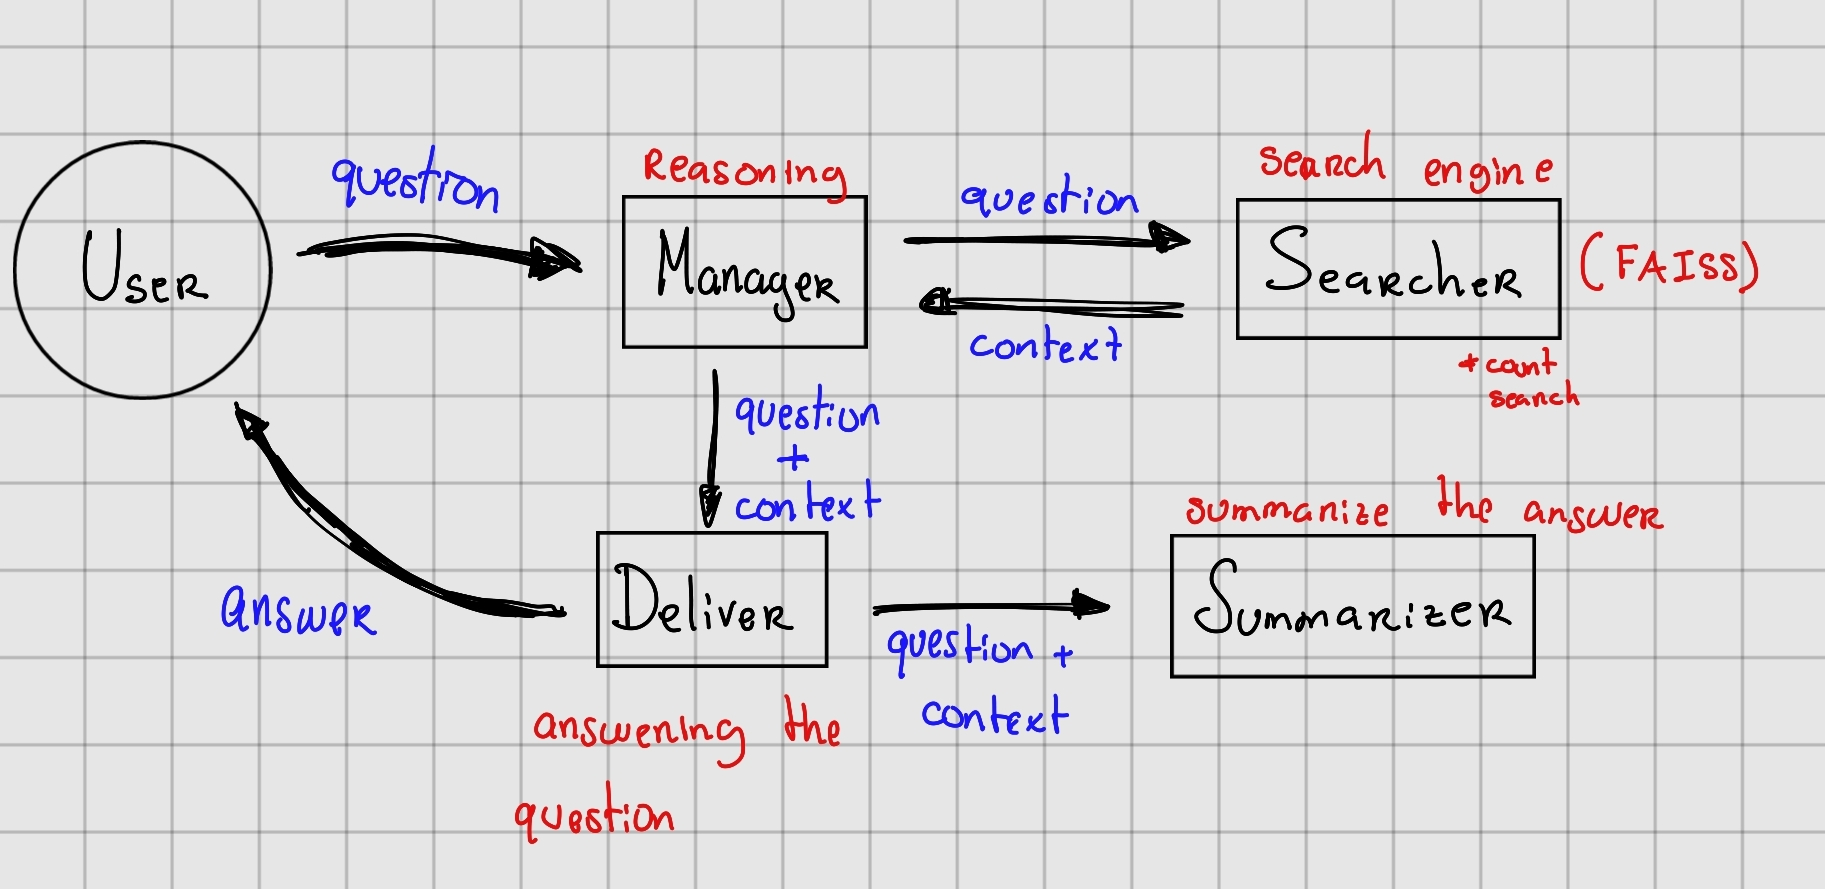

In [ ]:
def build_graph(llm=llm, max_steps:int=7, max_searches:int=3, display_it:bool=True, verbose:bool=True):
  '''
    Contrução do grafo para multiagentes (manager, searcher, deliver e summarizer)
  '''

  # definição do modelo
  llm_model = llm

  # prompts para cada agente
  prompts = {
      'manager' : """
      Você é um assistente especializado no Imposto de Renda de Pessoas Físicas (IRPF).

      Sua função é decidir a partir do contexto que recebeu se é capaz de responder a questão abaixo.
      Importante: quando não houver informação suficiente escreva 'SEARCH', para buscar mais informações no banco de dados.
      Caso avaliar que possui as informações necessárias escreva 'ANSWER', para finalizar a resposta. Toda resposta que fornecer
      deve justificar sua decisão, deixando claro seu raciocínio. A justificativa deve ter até 80 palavras.

      O formato da sua saída dever ser:
      "DECISÃO" : "JUSTIFICATIVA"
      por exemplo, SEARCH : considerando meu dados ...

      Abaixo se encontra o contexto e a pergunta.
      """,
      'deliver' : """
      Você é Leo, agente da Receita Federal. É um assistente especializado no Imposto de Renda de Pessoas Físicas (IRPF).
      Seja bem humorado e sempre incetive o usuário a seguir as leis e ser um cidadão do bem.
      Com base no contexto abaixo, sua função é responder de forma clara e direta a pergunta abaixo.
      Sempre que possível, cite a fonte ou base legal. Sua resposta deve ter até 150 palavras.
      """,
      'summerize' : """
      Resuma o texto a seguir para até 50 palavras.
      """
  }

  class State(TypedDict):
    '''
      Estrutura da mensagem trocada entre os nós
    '''
    count : int # contador para controlar número de passos
    count_searches : int # contador do número de buscas
    question : str # armazeno questão original
    context : list # informações recuperadas
    reasoning : list # decisões do modelo
    answer : str # resposta final do modelo
    hist : list # lista do histórico de conversas -> (pergunta, resumo da resposta)

  def search(state:State, k:int=3):
    '''
      Função para buscar documentos relevantes (agente de busca)
    '''
    # contagens
    state['count'] += 1
    state['count_searches'] += 1
    if (verbose) :
      print(f'[SEARCHER] : {state["count"]=} | {state["count_searches"]=}')
    # procura dos textos semanticamente próximos
    near_index = index.similarity_search(state['question'], k)
    state['context'].extend([f"informação {i + 3*(state['count_searches']-1)}: {doc.page_content}"
                             for i, doc in enumerate(near_index, 1)]
                            )
    return state

  def manage(state:State):
    '''
      Função para pensar na decisão do próximo passo (agente administrador ou gerente)
    '''
    # contagem
    state['count'] += 1
    if (verbose) :
      print(f'[MANAGER] : {state["count"]=} | {state["count_searches"]=}')
    # montagem do prompt considerando mensagem padrão, contextos e questão
    context = "\n".join(state['context'])
    prompt = prompts['manager'] + "\nCONTEXTOS:\n" + context + "\nQUESTÃO:\t" + state['question']
    # caso tenha, adiciono as mensagens já trocadas
    if len(state['hist']):
      hist = "\n".join([f"Usuário: {q}\nLeo: {a}" for q, a in state['hist']])
      prompt += f"\n\nHistórico de conversa:\n{hist}"
    response = llm_model.invoke([HumanMessage(content=prompt)])
    state['reasoning'].append(response.content) # aqui adiciono a justificativa da decisão do agente
    return state

  def answer(state:State):
    '''
      Função para geração da resposta final (agente de entrega)
    '''
    # contagem
    state['count'] += 1
    if (verbose) :
      print(f'[ANSWER] : {state["count"]=} | {state["count_searches"]=}')
    # como prompt temos a mensagem padrão, os contextos e a questão
    context = "\n".join(state['context'])
    prompt = prompts['deliver'] + "\nCONTEXTOS:\n" + context + "\nQUESTÃO:\t" + state['question']
    response = llm_model.invoke([HumanMessage(content=prompt)])
    state['answer'] = response.content
    return state

  def summarize(state:State):
    '''
      Função para resumir a resposta final (agente resumidor) --> serve para reduzir o tamanho da resposta final, assim, ocupando menos espaço
      no histórico de mensagens
    '''
    if (verbose) :
      print(f'[SUMMARIZE] : {state["count"]=} | {state["count_searches"]=}')
    prompt = prompts['summerize'] + "\nTEXTO" + state['answer']
    response = llm_model.invoke([HumanMessage(content=prompt)])
    state['hist'].append((state['question'], response.content))
    return state

  def router(state:State):
    '''
      Condições para próximos passos (dependendo da resposta do manager)
    '''
    last_decision = state['reasoning'][-1].upper()
    if (verbose) :
      print(f'[ROUTER] : {state["count"]=} | {state["count_searches"]=}')
    if state['count'] >= max_steps or state['count_searches'] >= max_searches:
      return 'deliver'
    elif 'SEARCH' in last_decision:
      return 'searcher'
    elif 'ANSWER' in last_decision:
      return 'deliver'
    else:
      return 'manager'

  # inicializando grafo
  graph = StateGraph(State)
  # definindo os nós
  graph.add_node('searcher', search)
  graph.add_node('manager', manage)
  graph.add_node('deliver', answer)
  graph.add_node('summarizer', summarize)
  # definindo fluxo
  graph.add_edge(START, 'manager')
  graph.add_conditional_edges('manager', router)
  graph.add_edge('searcher', 'manager')
  graph.add_edge('deliver', 'summarizer')
  graph.add_edge('summarizer', END)
  # criação do grafo
  graph_final = graph.compile()
  # representação do grafo
  if (display_it):
    display(Image(graph_final.get_graph().draw_mermaid_png()))

  return graph_final

Inicializando os agentes

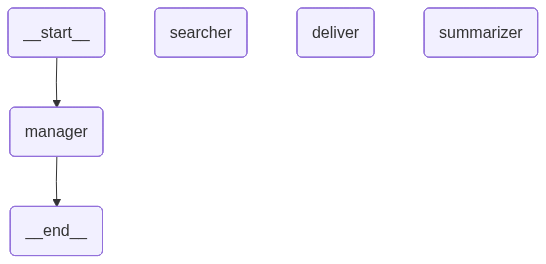

In [ ]:
MultiAgent = build_graph()

Verificando o funcionamento

In [ ]:
%%time
chat_data = MultiAgent.invoke({
    'count' : 0,
    'count_searches' : 0,
    'question' : 'Quem deve declarar o imposto de renda?',
    'context' : [],
    'reasoning' : [],
    'answer' : "",
    'hist': []
})

[MANAGER] : state["count"]=1 | state["count_searches"]=0
[ROUTER] : state["count"]=1 | state["count_searches"]=0
[SEARCHER] : state["count"]=2 | state["count_searches"]=1
[MANAGER] : state["count"]=3 | state["count_searches"]=1
[ROUTER] : state["count"]=3 | state["count_searches"]=1
[SEARCHER] : state["count"]=4 | state["count_searches"]=2
[MANAGER] : state["count"]=5 | state["count_searches"]=2
[ROUTER] : state["count"]=5 | state["count_searches"]=2
[SEARCHER] : state["count"]=6 | state["count_searches"]=3
[MANAGER] : state["count"]=7 | state["count_searches"]=3
[ROUTER] : state["count"]=7 | state["count_searches"]=3
[ANSWER] : state["count"]=8 | state["count_searches"]=3
[SUMMARIZE] : state["count"]=8 | state["count_searches"]=3
CPU times: user 409 ms, sys: 20.7 ms, total: 430 ms
Wall time: 1min 50s


Imprimindo todas as variáveis

In [ ]:
for key in chat_data.keys():
  print(f'[{key.upper()}] : {chat_data[key]}')
  print(30*'-')

[COUNT] : 8
------------------------------
[COUNT_SEARCHES] : 3
------------------------------
[QUESTION] : Quem deve declarar o imposto de renda?
------------------------------
[CONTEXT] : ['informação 1: . A pessoa jurídica que apurou o imposto de renda sobre a basede cálculo estimada no mês de dezembro poderá deduzir o impostopago no exterior até 31 de março de 1999', 'informação 2: . Linha 5 - Imposto sobre a Renda Retido na Fonte (IRRF). Informar o total do IRRF sobre os rendimentos informados na Linha 1. Linha 6 - Rendimentos isentos de pensão, proventos de aposentadoria ou reforma por moléstia grave ou aposentadoria ou reforma por acidente em serviço', 'informação 3: . 154. Seção V Das Demais Disposições Relativas ao Imposto sobre a Renda da Pessoa Física (IRPF) e à CPSS Art. 21. Caso não seja efetuada a devolução prevista no art. 17 nem a dedução prevista no art. 18, a pessoa física poderá requerer à RFB a restituição do indébito de imposto sobre a renda retido sobre rendimento

---
## Avaliação

Obtendo questões

In [ ]:
questions_link = r'https://huggingface.co/datasets/unicamp-dl/BR-TaxQA-R/resolve/main/questions_QA_2024_v1.0.json'
questions_request = requests.get(questions_link)
questions = questions_request.json()

Filtragem simples - Removo questões sem referências e obtenho as N primeiras

In [ ]:
N_QUESTIONS = 100
all_questions = [q['question_text'] for q in questions if len(q['all_formatted_references']) > 0][:N_QUESTIONS]

Passando questões para o multiagentes

In [ ]:
# lista que irei armazenar todas as informações necessárias
refs = []
# agente utilizado
MultiAgent = build_graph(display_it=False, verbose=False)
for question in tqdm(all_questions, ncols=100):
  chat_data = MultiAgent.invoke({
    'count' : 0,
    'count_searches' : 0,
    'question' : question,
    'context' : [],
    'reasoning' : [],
    'answer' : "",
    'hist': []
  })
  refs.append(chat_data) # obtendo todo o dicionário

100%|██████████████████████████████████████████████████████████| 100/100 [2:51:25<00:00, 102.86s/it]


### Metrificação

#### Métricas de baseadas na similaridade

* Média da similaridade do cosseno entre Questão e Documentos recuperados - estou avaliando a qualidade da recuperação. Semantica entre questão e documentos. Quanto mais próximo de 1 melhor. (*Query-Doc Similarity*)

* A partir da similaridade do cosseno avalio a diversidade entre os próprios documentos recuperados. Quanto mais próximo de 1 melhor. (*Intra-Retrieval Diversity*)

* Verifico o quanto a resposta está fundamentada nos documentos recuperados.  (*Groundedness*)

* Verifico a similaridade entre Questão e Resposta, ou seja, a coerência geral entre pergunta e resposta. (*Query-Answer Similarity*)


In [ ]:
def evaluate(query, docs, answer, embed_model=model) -> dict:
    """
      Cálculo das métricas listadas anteriormente
    """

    # Embeddings da query e da resposta
    emb_q = np.array(embed_model.embed_query(query)).reshape(1, -1)
    emb_a = np.array(embed_model.embed_query(answer)).reshape(1, -1)

    # Similaridade pergunta-resposta (coerência)
    qa_sim = cosine_similarity(emb_q, emb_a)[0][0]

    # Caso não tenha sido requerido contextos
    if not docs or len(docs) == 0:
        return {
            "cos_sim": None,
            "diversity": None,
            "groundedness": None,
            "qa_Sim": qa_sim
        }

    # Embeddings dos documentos de contexto (chunks)
    emb_d = np.array(embed_model.embed_documents(docs))
    if emb_d.ndim == 1:  # caso tenha apenas 1 documento
        emb_d = emb_d.reshape(1, -1)
    # mean query-doc cos similarity
    # Média da similaridade do cosseno (qualidade da recuperação)
    cos_sim = np.mean(cosine_similarity(emb_q, emb_d)[0])

    # Diversidade na recuperação
    n = len(emb_d)
    if n > 1:
        sim_docs = cosine_similarity(emb_d) # similaridade
        upper = np.triu_indices(n, k=1) # apenas pares únicos (parte superior da matriz)
        diversity = 1 - np.mean(sim_docs[upper]) # 1 - média(sim_cos) = oposto da similaridade = diversidade
    else:
        diversity = 0.0  # diversidade nula com apenas 1 documento (apenas para prevenir, mas não teremos este caso)

    # groundedness (o quanto a resposta está baseada nos documentos recuperados)
    groundedness = np.mean(cosine_similarity(emb_a, emb_d)[0])

    return {
        "cos_sim": cos_sim,
        "diversity": diversity,
        "groundedness": groundedness,
        "qa_Sim": qa_sim
    }

In [ ]:
for i, ref in enumerate(tqdm(refs, ncols=100)):
  refs[i]['validation']  = evaluate(ref['question'], ref['context'], ref['answer'])

100%|█████████████████████████████████████████████████████████████| 100/100 [05:44<00:00,  3.44s/it]


In [ ]:
cos_sim = [ref['validation']['cos_sim'] for ref in refs if ref['validation']['cos_sim'] != None]
diversity = [ref['validation']['diversity'] for ref in refs if ref['validation']['diversity'] != None]
groundedness = [ref['validation']['groundedness'] for ref in refs if ref['validation']['groundedness'] != None]
qa_Sim = [ref['validation']['qa_Sim'] for ref in refs]

Plotando métricas

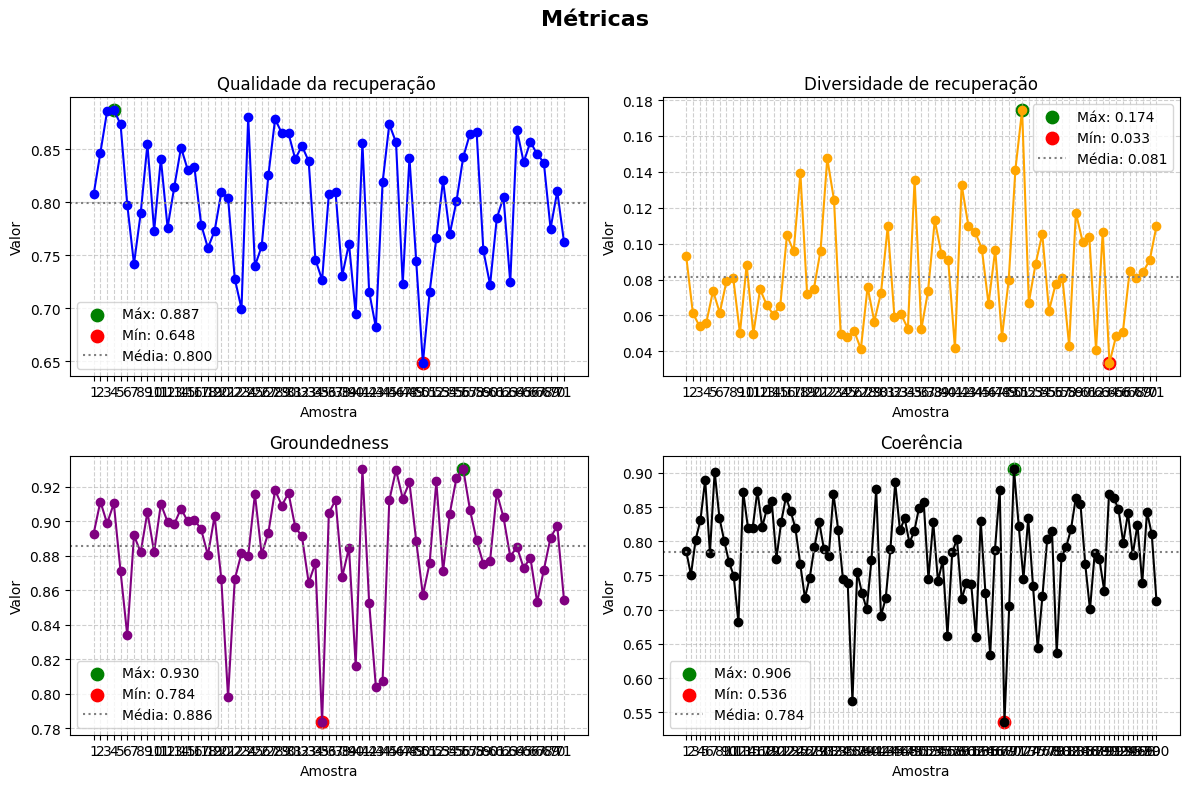

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Métricas", fontsize=16, fontweight="bold")

# Query-Doc Similarity
data = cos_sim
ax = axes[0, 0]
ax.plot(data, color='blue', marker='o')
ax.set_title("Qualidade da recuperação ")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel("Amostra")
ax.set_ylabel("Valor")

idx_max = data.index(max(data))
idx_min = data.index(min(data))
mean_val = sum(data) / len(data)

ax.scatter(idx_max, max(data), color='green', s=80, label=f'Máx: {max(data):.3f}')
ax.scatter(idx_min, min(data), color='red', s=80, label=f'Mín: {min(data):.3f}')
ax.axhline(y=mean_val, color='gray', linestyle=':', linewidth=1.5, label=f'Média: {mean_val:.3f}')
ax.legend()
ax.set_xticks(range(len(data)))
ax.set_xticklabels(range(1, len(data) + 1))

# Intra-Retrieval Diversity
data = diversity
ax = axes[0, 1]
ax.plot(data, color='orange', marker='o')
ax.set_title("Diversidade de recuperação")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel("Amostra")
ax.set_ylabel("Valor")

idx_max = data.index(max(data))
idx_min = data.index(min(data))
mean_val = sum(data) / len(data)

ax.scatter(idx_max, max(data), color='green', s=80, label=f'Máx: {max(data):.3f}')
ax.scatter(idx_min, min(data), color='red', s=80, label=f'Mín: {min(data):.3f}')
ax.axhline(y=mean_val, color='gray', linestyle=':', linewidth=1.5, label=f'Média: {mean_val:.3f}')
ax.legend()
ax.set_xticks(range(len(data)))
ax.set_xticklabels(range(1, len(data) + 1))

# Groundedness
data = groundedness
ax = axes[1, 0]
ax.plot(data, color='purple', marker='o')
ax.set_title("Groundedness")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel("Amostra")
ax.set_ylabel("Valor")

idx_max = data.index(max(data))
idx_min = data.index(min(data))
mean_val = sum(data) / len(data)

ax.scatter(idx_max, max(data), color='green', s=80, label=f'Máx: {max(data):.3f}')
ax.scatter(idx_min, min(data), color='red', s=80, label=f'Mín: {min(data):.3f}')
ax.axhline(y=mean_val, color='gray', linestyle=':', linewidth=1.5, label=f'Média: {mean_val:.3f}')
ax.legend()
ax.set_xticks(range(len(data)))
ax.set_xticklabels(range(1, len(data) + 1))

# Query-Answer Similarity
data = qa_Sim
ax = axes[1, 1]
ax.plot(data, color='black', marker='o')
ax.set_title("Coerência")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlabel("Amostra")
ax.set_ylabel("Valor")

idx_max = data.index(max(data))
idx_min = data.index(min(data))
mean_val = sum(data) / len(data)

ax.scatter(idx_max, max(data), color='green', s=80, label=f'Máx: {max(data):.3f}')
ax.scatter(idx_min, min(data), color='red', s=80, label=f'Mín: {min(data):.3f}')
ax.axhline(y=mean_val, color='gray', linestyle=':', linewidth=1.5, label=f'Média: {mean_val:.3f}')
ax.legend()
ax.set_xticks(range(len(data)))
ax.set_xticklabels(range(1, len(data) + 1))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

A partir dos gráficos notamos que a qualidade de recuperação está boa. Imagino que isso ocorra, pois o utilizo dessa métrica para fazer a recuperação, logo, era algo esperado. Com relação à diversidade vemos que os valores são baixos, algo que considero esperado, pois os textos recuperados são baseados na proximidade com a pergunta (uma mesma referência), portanto, devem ser próximos entre si. Pela métrica do *Groundedness* notamos que nosso modelo fundamentou suas respostas muito fortemente nos textos recuperados (deixando claro que não fugiu do assunto). Por fim, temos que a métrica de coerência está alta. Isso é esperado considerando as métricas altas de qualidade de recuperação e *groundedness*.

### Avaliação de uma LLM juiz (gpt-5-nano)

In [ ]:
def prompt_val(question, answer, docs) -> str:
  return f"""
    Avalie a resposta do chatbot em relação à pergunta e ao contexto.
    Dê notas de 1 a 5 para:
    1. Relevância da resposta à pergunta
    2. Fidelidade ao contexto (caso não tenha contexto pode retornar 0)
    3. Clareza e coerência do texto

    Pergunta: {question}
    Contexto : {docs}
    Resposta: {answer}

    Retorne no formato:
    relevancia: nota
    fidelidade: nota
    coerencia: nota
  """

In [ ]:
# padrão da resposta gerada pela LLM
pattern = r"(\w+):\s*([0-9])"
for i, ref in enumerate(tqdm(refs)):
  question = ref['question']
  docs = '\n'.join(ref['context'])
  answer = ref['answer']

  llm_val = llm.invoke(prompt_val(question, answer, docs))

  response = llm_val.content
  matches = re.findall(pattern, response.lower())
  # adiciono no dicionário de informações
  refs[i]['validation']['val_llm'] = {
      k: int(v)
      for k, v in matches
  }

100%|██████████| 100/100 [23:16<00:00, 13.96s/it]


In [ ]:
relevance = [ref['validation']['val_llm']['relevancia'] for ref in refs]
fidelity = [ref['validation']['val_llm']['fidelidade'] for ref in refs if ref['validation']['val_llm']['fidelidade'] != 0] # ignoro casos sem contexto
coherence = [ref['validation']['val_llm']['coerencia'] for ref in refs]

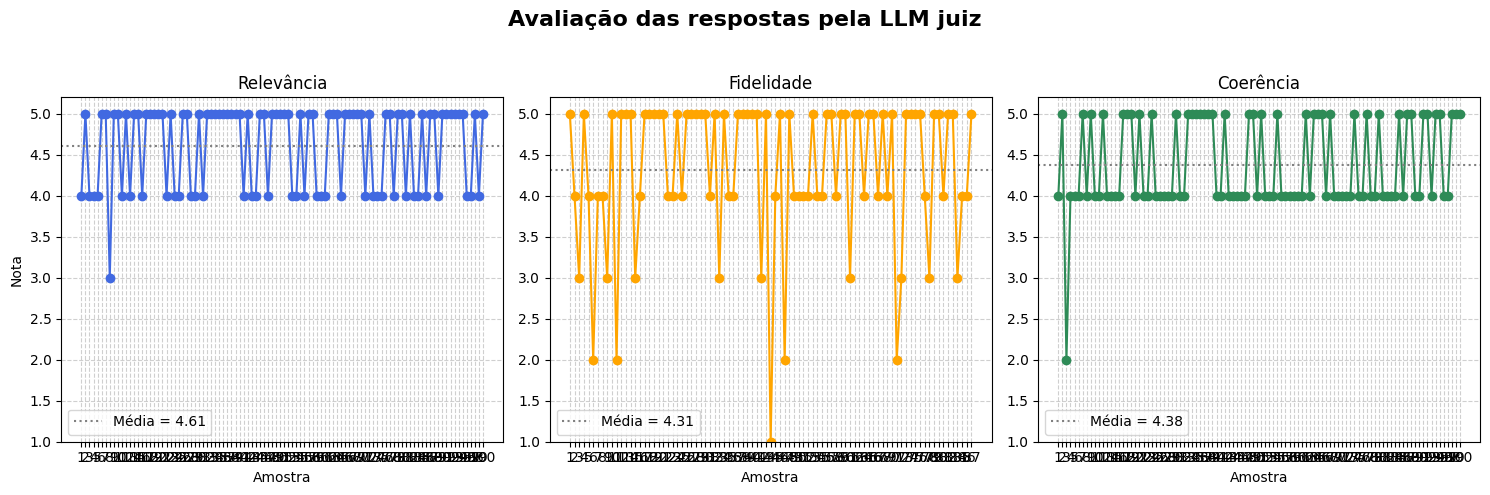

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Avaliação das respostas pela LLM juiz", fontsize=16, fontweight='bold')

# Relevância
data = relevance
ax = axes[0]
ax.plot(range(1, len(data) + 1), data, marker='o', color='royalblue')
ax.set_title("Relevância")
ax.set_ylim(1, 5.2)
ax.set_xlabel("Amostra")
ax.set_ylabel("Nota")
ax.grid(True, linestyle='--', alpha=0.6)
mean_val = sum(data) / len(data)
ax.axhline(y=mean_val, color='gray', linestyle=':', label=f"Média = {mean_val:.2f}")
ax.set_xticks(range(1, len(data) + 1))
ax.legend()

# Fidelidade
data = fidelity
ax = axes[1]
ax.plot(range(1, len(data) + 1), data, marker='o', color='orange')
ax.set_title("Fidelidade")
ax.set_ylim(1, 5.2)
ax.set_xlabel("Amostra")
ax.grid(True, linestyle='--', alpha=0.6)
mean_val = sum(data) / len(data)
ax.axhline(y=mean_val, color='gray', linestyle=':', label=f"Média = {mean_val:.2f}")
ax.set_xticks(range(1, len(data) + 1))
ax.legend()

# Coerência
data = coherence
ax = axes[2]
ax.plot(range(1, len(data) + 1), data, marker='o', color='seagreen')
ax.set_title("Coerência")
ax.set_ylim(1, 5.2)
ax.set_xlabel("Amostra")
ax.grid(True, linestyle='--', alpha=0.6)
mean_val = sum(data) / len(data)
ax.axhline(y=mean_val, color='gray', linestyle=':', label=f"Média = {mean_val:.2f}")
ax.set_xticks(range(1, len(data) + 1))
ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

A partir dos gráficos notamos que grande parte dos conjuntos de pergunta, contexto e resposta possuem boas notas, porém, vejo que ao utilizar um mesmo modelo de LLM para os agentes e para a avaliação isso gerou um certa "trapaça", pois imagino que todos os parâmetros do modelo levam ele a reposder de tal forma uma pergunta, logo, se pedirmos para a mesma (considerando ela sem acesso ao histórico) avaliar a resposta é esperado que considere uma boa resposta.

### Todas as informações armazenadas

Todas as informações (para verificação do funcionamento da recuperação e do agente no geral)

In [ ]:
for i, ref in enumerate(refs, 1):
    print(30*'=')
    print(f'####################### Questão {i} ###############################')
    print(f'[COUNT] : {ref["count"]}\n{30*"-"}')
    print(f'[COUNT SEARCHES] : {ref["count_searches"]}\n{30*"-"}')
    print(f'[QUESTION] : {ref["question"]}\n{30*"-"}')
    print(f'[CONTEXT] :\n{"\n".join(ref["context"])}\n{30*"-"}')
    print(f'[REASONING] :\n{"\n".join(ref["reasoning"])}\n{30*"-"}')
    print(f'[ANSWER] :\n{ref["answer"]}\n{30*"-"}')
    print(f'[HIST] : {"\n".join([f"\nQuestion: {q}\nAnswer: {a}" for q, a in ref["hist"]])}\n{30*"-"}')

    val = ref.get('validation', {})
    cos_sim = val.get('cos_sim')
    diversity = val.get('diversity')
    groundedness = val.get('groundedness')
    qa_Sim = val.get('qa_Sim')

    # função para converter None para N/A
    def fmt(x): return f"{x:.4f}" if isinstance(x, (float, int)) else "N/A"
    print(f"[METRICS]:\n"
          f"cos_sim = {fmt(cos_sim)}\n"
          f"diversity = {fmt(diversity)}\n"
          f"groundedness = {fmt(groundedness)}\n"
          f"qa_Sim = {fmt(qa_Sim)}")

    val_llm = val.get('val_llm', {})
    relevance = val_llm.get('relevancia', 'N/A')
    fidelity = val_llm.get('fidelidade', 'N/A')
    coherence = val_llm.get('coerencia', 'N/A')

    print(f"relevance = {relevance}\n"
          f"fidelity = {fidelity}\n"
          f"coherence = {coherence}")


####################### Questão 1 ###############################
[COUNT] : 8
------------------------------
[COUNT SEARCHES] : 3
------------------------------
[QUESTION] : Quem está obrigado a apresentar a Declaração de Ajuste Anual relativa ao exercício de 2024, ano-calendário de 2023?
------------------------------
[CONTEXT] :
informação 1: . 36 em relação às participações em entidades controladas detidas em 31 de dezembro de 2023 deverá: I - indicar a sua opção na DAA a ser entregue em 2024, dentro do prazo, relativa ao ano-calendário de 2023, para produzir efeitos a partir de 1º de janeiro de 2024
informação 2: . DECLARA, em caráter normativo, às Superintendências Regionais da Receita Federal e aos demais interessados que: 1. O Demonstrativo da Apuração dos Ganhos de Capital de que trata o subitem 8.3 da IN RF 19/91, a ser anexado à Declaração de Rendimentos do exercício de 1991, é o do ano-base de 1989, exercício de 1990, adaptado à legislação tributária em vigor no ano-base de 

---
## Leo 🦁

Breve apresentação da interface do chatbot

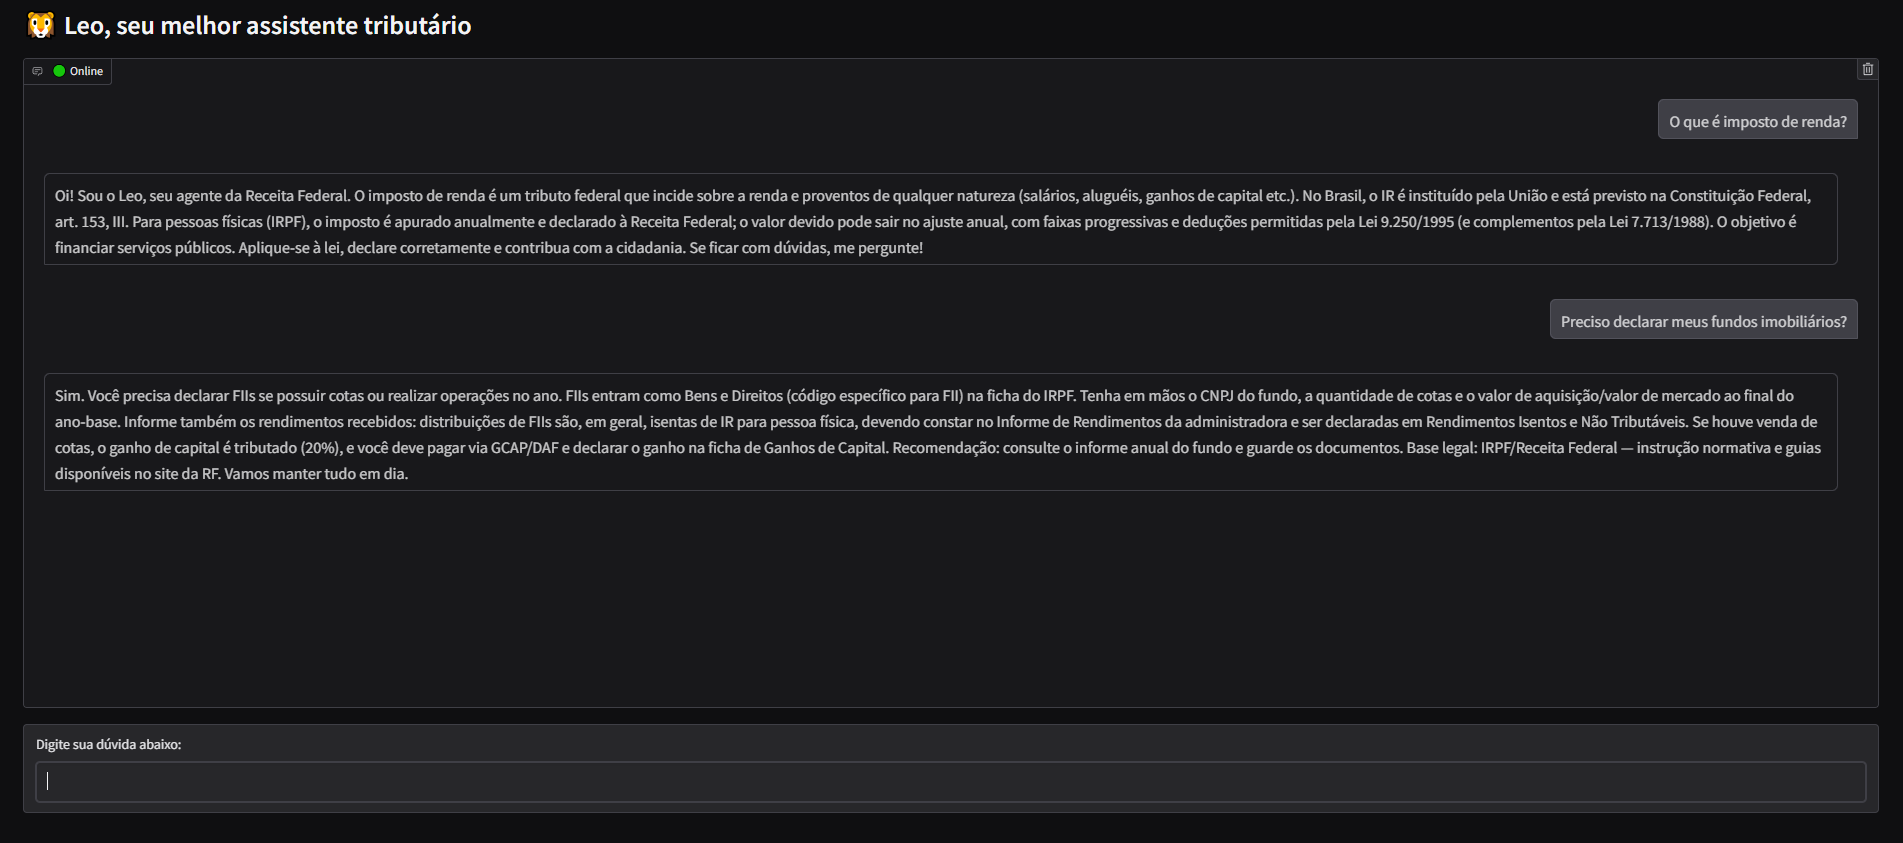

In [ ]:
class LeoAI:
    def __init__(self, llm=llm, debug:bool=True):
      self.llm = llm
      self.local_chat_hist = []
      self.state = {
          "count": 0,
          "count_searches": 0,
          "question": "",
          "context": [],
          "reasoning": [],
          "answer": "",
          "hist": []
      }
      self.agent = build_graph(llm=llm, display_it=False)
      self.ui = self.gradio_ui()
      self.ui.launch(inline=False, inbrowser=True, debug=debug)

    # Mostra a pergunta + status pensando
    def show_typing(self, question):
      if len(question) < 1:
        self.local_chat_hist, gr.update(value="")
      self.local_chat_hist.append((question, "🧠 Leo está pensando"))
      # Retorna o chat atualizado e limpa a caixa de texto
      return self.local_chat_hist, gr.update(value="")

    # Envia a pergunta para o LLM e atualiza a resposta
    def get_answer(self, question):
      if len(question) < 1: # caso usuário envie uma pergunta vazia
        return self.local_chat_hist
      self.state['question'] = question
      new_state = self.agent.invoke(self.state)  # seu grafo multiagente
      answer = new_state['answer']
      self.state = self.adjust_state(new_state)
      # Atualiza o chat substituindo a mensagem temporária
      self.local_chat_hist[-1] = (question, answer)
      return self.local_chat_hist

    def adjust_state(self, state, lim_context:int=10, lim_hist:int=600):
      ''' função para ajustar o dicionário'''
      state['count'] = 0
      state['count_searches'] = 0
      state['reasoning'] = []
      if len(state['context']) > lim_context:
        state['context'] = [] # zero o contexto
      if len(state['hist']) > lim_hist:
        state['hist'] = state['hist'][1:] # removo o par mais antigo
      return state

    def gradio_ui(self):
      with gr.Blocks() as ui:
          gr.Markdown("# 🦁 Leo, seu melhor assistente tributário")

          chatbox = gr.Chatbot(
              label="🟢 Online",
              type="tuples",
              elem_id="chatbox",
              height=650
          )
          user_input = gr.Textbox(
              label="Digite sua dúvida abaixo:"
          )

          question_state = gr.State()


          # Fluxo
          user_input.submit(
              fn=lambda q: (q, q),
              inputs=[user_input],
              outputs=[question_state, user_input]
          ).then(
              fn=self.show_typing,
              inputs=[question_state],
              outputs=[chatbox, user_input]
          ).then(
              fn=self.get_answer,
              inputs=[question_state],
              outputs=[chatbox]
          )

      return ui

In [ ]:
LeoAI(debug=True)

/tmp/ipython-input-3588754992.py:53: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  chatbox = gr.Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8adb471c07a2a98d54.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
[MANAGER] : state["count"]=1 | state["count_searches"]=0
[ROUTER] : state["count"]=1 | state["count_searches"]=0
[ANSWER] : state["count"]=2 | state["count_searches"]=0
[SUMMARIZE] : state["count"]=2 | state["count_searches"]=0
[MANAGER] : state["count"]=1 | state["count_searches"]=0
[ROUTER] : state["count"]=1 | state["count_searches"]=0
[ANSWER] : state["count"]=2 | state["count_